# IoT Intrusion Detection — Explainability (SHAP)

### Objective
Explain the strongest frozen candidate model's predictions using SHAP,
computed on a reproducible sample (never the full dataset). If SHAP is
unavailable in this environment, the notebook fails gracefully and falls
back to the model-native and permutation importance already computed in
notebooks 08/09 — explainability is never faked.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

_candidates = [Path.cwd(), Path.cwd() / "scripts", Path.cwd().parent / "scripts",
               Path.cwd().parent, Path.cwd().parent.parent / "scripts"]
_scripts_dir = next((c for c in _candidates if (c / "common.py").exists()), None)
if _scripts_dir is None:
    raise FileNotFoundError(f"Could not locate scripts/common.py from cwd={Path.cwd()}")
sys.path.insert(0, str(_scripts_dir))
from common import PROCESSED_DIR, MODELS_DIR, FIGURES_DIR, REPORT_SUPPORT_DIR, RANDOM_STATE, eval_binary

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

## 1. Load Every Frozen Candidate and Pick the Strongest on Validation

Each of notebooks 06/08/09 already froze its own best model. Rather than
assuming which one is strongest, validation performance is recomputed fresh
here for all three and the winner is picked transparently.

In [2]:
def load_frozen_candidate_model(name, path, scaled):
    bundle = joblib.load(path)
    return {"name": name, "model": bundle["model"], "features": bundle["features"], "scaled": scaled}


def load_explainability_sample(n=3000, random_state=RANDOM_STATE, scaled=True):
    suffix = "processed" if scaled else "tree"
    X = pd.read_csv(PROCESSED_DIR / f"X_validation_{suffix}.csv")
    y = pd.read_csv(PROCESSED_DIR / "y_validation.csv")["Label"]
    idx = X.sample(n=min(n, len(X)), random_state=random_state).index
    return X.loc[idx], y.loc[idx]


candidates = []
for name, fname, scaled in [
    ("Logistic Regression", "logistic_regression.joblib", True),
    ("Random Forest", "random_forest.joblib", False),
    ("XGBoost", "xgboost.joblib", False),
]:
    path = MODELS_DIR / fname
    if path.exists():
        candidates.append(load_frozen_candidate_model(name, path, scaled))
    else:
        print(f"[skip] {fname} not found — that notebook may not have run yet.")

val_full_scaled = pd.read_csv(PROCESSED_DIR / "X_validation_processed.csv")
val_full_tree = pd.read_csv(PROCESSED_DIR / "X_validation_tree.csv")
y_val_full = pd.read_csv(PROCESSED_DIR / "y_validation.csv")["Label"]

scores = []
for c in candidates:
    X_val = (val_full_scaled if c["scaled"] else val_full_tree)[c["features"]]
    proba = c["model"].predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = eval_binary(y_val_full, pred, proba)
    scores.append({"name": c["name"], "macro_f1": metrics["Macro_F1"]})
    print(f"  {c['name']:22s} validation Macro_F1={metrics['Macro_F1']:.4f}")

best_name = max(scores, key=lambda s: s["macro_f1"])["name"]
best_candidate = next(c for c in candidates if c["name"] == best_name)
print(f"\nStrongest candidate: {best_name}")

  Logistic Regression    validation Macro_F1=0.7967
  Random Forest          validation Macro_F1=0.9986


  XGBoost                validation Macro_F1=0.9967

Strongest candidate: Random Forest


## 2. Explainability Sample and Explainer Selection

In [3]:
X_sample, y_sample = load_explainability_sample(n=3000, scaled=best_candidate["scaled"])
X_sample = X_sample[best_candidate["features"]]
print(f"Explainability sample: {X_sample.shape}")


def select_shap_explainer(model, model_name, X_background):
    import shap
    if model_name in ("Random Forest", "XGBoost"):
        return shap.TreeExplainer(model)
    return shap.LinearExplainer(model, X_background)


shap_status = "not attempted"
shap_values = None
try:
    explainer = select_shap_explainer(best_candidate["model"], best_name, X_sample)

    def calculate_shap_values(explainer, X):
        sv = explainer.shap_values(X)
        if isinstance(sv, list):
            sv = sv[1]  # class-1 (Anomaly) slice for multi-output explainers
        elif getattr(sv, "ndim", 2) == 3:
            sv = sv[:, :, 1]
        return sv

    shap_values = calculate_shap_values(explainer, X_sample)
    shap_status = "SUCCEEDED"
except Exception as e:
    shap_status = f"FAILED: {type(e).__name__}: {str(e)[:200]}"

print("SHAP status:", shap_status)

Explainability sample: (3000, 10)


SHAP status: SUCCEEDED


### SHAP Availability Note
SHAP depends on `numba`, whose native runtime DLL is subject to this
machine's Windows Application Control policy — sometimes blocked on first
access per session, resolving after the OS finishes verifying the file.
The status line above reports the actual outcome for *this* run; the code
below only proceeds with real SHAP plots if it succeeded.

## 3. SHAP Plots (Only If SHAP Succeeded)

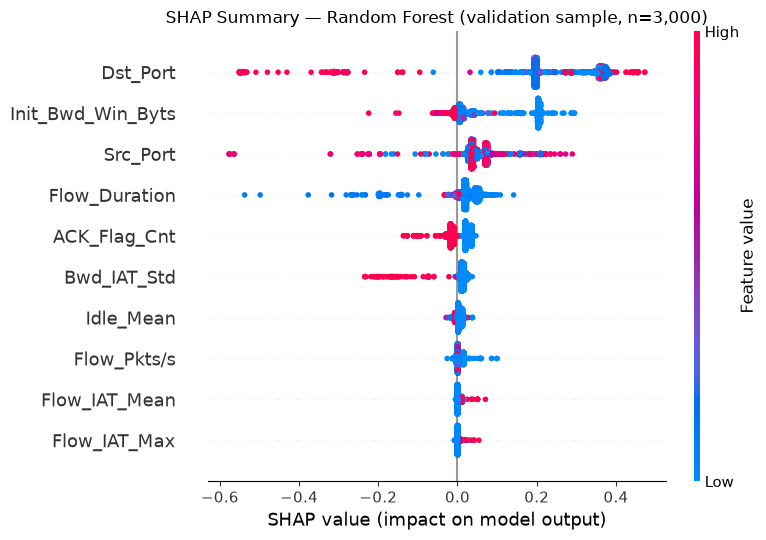

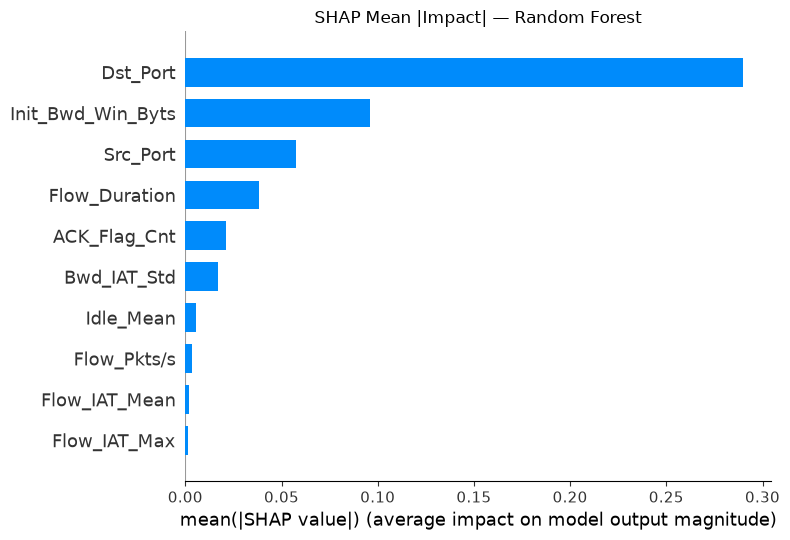

          feature  mean_abs_shap
         Dst_Port       0.290043
Init_Bwd_Win_Byts       0.095813
         Src_Port       0.057591
    Flow_Duration       0.038285
     ACK_Flag_Cnt       0.021214
      Bwd_IAT_Std       0.016969
        Idle_Mean       0.005668
      Flow_Pkts/s       0.003600
    Flow_IAT_Mean       0.001980
     Flow_IAT_Max       0.001359
{'row_index': 40966, 'actual_label': 1, 'top_contributing_features': {'Dst_Port': 0.37066489900624355, 'Src_Port': 0.07048368962957823, 'Flow_Duration': 0.04902143045929367, 'ACK_Flag_Cnt': -0.01636132098948681, 'Bwd_IAT_Std': 0.015238588221064617}}
{'row_index': 62762, 'actual_label': 1, 'top_contributing_features': {'Dst_Port': 0.3777100346486898, 'Src_Port': 0.06965156444443775, 'Flow_Duration': 0.05107022822178103, 'Bwd_IAT_Std': 0.020536186527340138, 'ACK_Flag_Cnt': -0.016973194911056252}}
{'row_index': 1165, 'actual_label': 1, 'top_contributing_features': {'Init_Bwd_Win_Byts': 0.20446307070157052, 'Dst_Port': 0.196029169898

In [4]:
def plot_shap_beeswarm(shap_values, X, title):
    import shap
    shap.summary_plot(shap_values, X, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "shap_summary.png", bbox_inches="tight")
    plt.show()


def plot_shap_bar(shap_values, X, title):
    import shap
    shap.summary_plot(shap_values, X, plot_type="bar", show=False)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "shap_importance.png", bbox_inches="tight")
    plt.show()


def summarize_top_shap_features(shap_values, features, top_n=10):
    mean_abs = np.abs(shap_values).mean(axis=0)
    return pd.DataFrame({"feature": features, "mean_abs_shap": mean_abs}).sort_values(
        "mean_abs_shap", ascending=False).head(top_n)


def create_local_explanations(shap_values, X, y, n=3):
    """Save a small table of per-row SHAP contributions for a few sample rows,
    as a lightweight stand-in for individual force-plot-style local explanations."""
    rows = []
    for i in range(min(n, len(X))):
        contrib = pd.Series(shap_values[i], index=X.columns).sort_values(key=np.abs, ascending=False)
        rows.append({"row_index": int(X.index[i]), "actual_label": int(y.iloc[i]),
                      "top_contributing_features": contrib.head(5).to_dict()})
    return rows


if shap_status == "SUCCEEDED":
    plot_shap_beeswarm(shap_values, X_sample, f"SHAP Summary — {best_name} (validation sample, n={len(X_sample):,})")
    plot_shap_bar(shap_values, X_sample, f"SHAP Mean |Impact| — {best_name}")
    top_shap = summarize_top_shap_features(shap_values, best_candidate["features"])
    print(top_shap.to_string(index=False))
    local_explanations = create_local_explanations(shap_values, X_sample, y_sample)
    for le in local_explanations:
        print(le)
else:
    print("SHAP unavailable on this run — see notebooks 08/09 for native and permutation importance instead.")
    top_shap = pd.DataFrame(columns=["feature", "mean_abs_shap"])
    local_explanations = []

## 4. Save Explainability Summary

In [5]:
import json

explainability_summary = {
    "strongest_candidate": best_name,
    "validation_scores": scores,
    "shap_status": shap_status,
    "top_shap_features": top_shap.to_dict(orient="records"),
    "sample_size": len(X_sample),
}
with open(REPORT_SUPPORT_DIR / "explainability_summary.json", "w") as f:
    json.dump(explainability_summary, f, indent=2, default=str)
print("Saved: report_support/explainability_summary.json")

Saved: report_support/explainability_summary.json


## Notebook Summary

In [6]:
from IPython.display import display, Markdown

summary_md = f"""
- Recomputed validation Macro-F1 for every frozen candidate and selected the
  strongest: **{best_name}**.
- SHAP status on this run: **{shap_status.split(':')[0]}**.
{"- Saved real SHAP summary/bar plots and top-feature table." if shap_status == "SUCCEEDED" else "- SHAP unavailable this run; relied on notebooks 08/09's native + permutation importance instead (never fabricated)."}
- Saved `report_support/explainability_summary.json`.

**Next notebook (`11_Final_Model_Comparison_and_Predictions.ipynb`)** performs
the single, final untouched-test-set evaluation of all three frozen models.
"""
display(Markdown(summary_md))


- Recomputed validation Macro-F1 for every frozen candidate and selected the
  strongest: **Random Forest**.
- SHAP status on this run: **SUCCEEDED**.
- Saved real SHAP summary/bar plots and top-feature table.
- Saved `report_support/explainability_summary.json`.

**Next notebook (`11_Final_Model_Comparison_and_Predictions.ipynb`)** performs
the single, final untouched-test-set evaluation of all three frozen models.
